<a href="https://colab.research.google.com/github/w3aarush/DR_Classification_NIT_MCA_Project/blob/main/DR_Dataset_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2S, preprocess_input
from tensorflow.keras import layers,Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# from tensorflow.keras.layers import Attention # This import is not used

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score
from google.colab.patches import cv2_imshow

import time
import os

# from cuml import SVC # for python 3.11
# from sklearn.svm import SVC
# import imutils

In [ ]:
# # Install Kaggle API
# !pip install -q kaggle

# # Upload kaggle.json
# from google.colab import files
# files.upload()

# # Setup Kaggle API
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/kaggle.json
# !chmod 600 ~/.kaggle/kaggle.json

# # Download DATASET (not competition)
# !kaggle datasets download -d mariaherrerot/aptos2019

# # Unzip
# !unzip -q aptos2019.zip -d aptos2019

# # Check files
# !ls aptos2019

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [01:31<00:00, 94.0MB/s]

test.csv  test_images  train_1.csv  train_images  valid.csv  val_images


In [ ]:
# base_dir = '/content/aptos2019'
# train_dir = '/content/aptos2019/train_images/train_images/'
# validation_dir = '/content/aptos2019/val_images/val_images/'
# test_dir = '/content/aptos2019/test_images/test_images/'

In [2]:
# from drive
base_dir = '/content/drive/MyDrive/aptos2019/'
train_img = '/content/drive/MyDrive/aptos2019/train_images/train_images/'
validation_img = '/content/drive/MyDrive/aptos2019/val_images/val_images/'
test_img = '/content/drive/MyDrive/aptos2019/test_images/test_images/'

train_csv = '/content/drive/MyDrive/aptos2019/train_1.csv'
test_csv = '/content/drive/MyDrive/aptos2019/test.csv'
valid_csv = '/content/drive/MyDrive/aptos2019/valid.csv'

In [3]:
NUM_CLASSES = 5
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
epochs = 20

### CLAHE

In [4]:
def apply_clahe_to_image_tensor(image_tensor):
    # image_tensor has shape (H, W, C) for a single image, float32, in [0, 255]
    # Convert to uint8 for OpenCV operations
    image_np_uint8 = tf.cast(image_tensor, tf.uint8).numpy()

    # Convert RGB to LAB color space to apply CLAHE only to the Lightness channel
    lab = cv2.cvtColor(image_np_uint8, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    # Apply CLAHE to the L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) # You can adjust clipLimit and tileGridSize
    cl = clahe.apply(l_channel)

    # Merge the CLAHE enhanced L channel with the original A and B channels
    limg = cv2.merge((cl, a_channel, b_channel))

    # Convert LAB back to RGB
    final_img_np_rgb = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # Convert back to float32 and return as TensorFlow tensor
    return tf.convert_to_tensor(final_img_np_rgb, dtype=tf.float32)

# Wrapper function to apply CLAHE to a batch of images using tf.map_fn
def apply_clahe_batch(images_batch_tensor):
    # tf.map_fn applies a function to each element (image) in the batch
    return tf.map_fn(
        fn=lambda img: tf.py_function(apply_clahe_to_image_tensor, [img], tf.float32),
        elems=images_batch_tensor,
        fn_output_signature=tf.TensorSpec(images_batch_tensor.shape[1:], dtype=tf.float32)
    )

In [5]:
img_augmentation = Sequential(
    [
        tf.keras.layers.Lambda(apply_clahe_batch), # Apply CLAHE first
        tf.keras.layers.RandomRotation(factor=(-0.15, 0.15)),
        tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        tf.keras.layers.RandomFlip(),
        tf.keras.layers.RandomContrast(factor=0.6),
    ],
    name="img_augmentation",
)

### loading dataset

In [6]:
def load_data():
    # train = pd.read_csv('/content/aptos2019/train_1.csv', encoding='utf-8')
    # test = pd.read_csv('/content/aptos2019/test.csv', encoding='utf-8')
    # valid = pd.read_csv('/content/aptos2019/valid.csv')

    train = pd.read_csv(train_csv, encoding='utf-8') # from drive
    test = pd.read_csv(test_csv, encoding='utf-8') # from drive
    valid = pd.read_csv(valid_csv) # from drive

    # train_dir = '/content/aptos2019/train_images/train_images/'
    # test_dir = '/content/aptos2019/test_images/test_images/'
    # valid_dir = '/content/aptos2019/val_images/val_images/'

    train_dir = train_img # from drive
    test_dir = test_img # from drive
    valid_dir = validation_img # from drive

    # construct file paths directly within function:
    train['image_path'] = train_dir + train['id_code'] + '.png'
    test['image_path'] = test_dir + test['id_code'] + '.png'
    valid['image_path'] = valid_dir + valid['id_code'] + '.png'

    train['train_images'] = train['id_code'] + '.png'
    test['test_images'] = test['id_code'] + '.png'
    valid['valid_images'] = valid['id_code'] + '.png'

    train['diagnosis'] = train['diagnosis'].astype(str)
    # train['target'] = [1 if x >= 1 else 0 for x in train['diagnosis']]
    # train['target'] = train['target'].astype(str)
    test['diagnosis'] = test['diagnosis'].astype(str)
    # test['target'] = [1 if x >= 1 else 0 for x in test['diagnosis']]
    # test['target'] = test['target'].astype(str)
    valid['diagnosis'] = valid['diagnosis'].astype(str)
    # valid['target'] = [1 if x >= 1 else 0 for x in valid['diagnosis']]
    # valid['target'] = valid['target'].astype(str)

    return train, test, valid

In [7]:
train_df, test_df, valid_df = load_data()

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_code       2930 non-null   object
 1   diagnosis     2930 non-null   object
 2   image_path    2930 non-null   object
 3   train_images  2930 non-null   object
dtypes: object(4)
memory usage: 91.7+ KB


In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_code      366 non-null    object
 1   diagnosis    366 non-null    object
 2   image_path   366 non-null    object
 3   test_images  366 non-null    object
dtypes: object(4)
memory usage: 11.6+ KB


In [10]:
valid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_code       366 non-null    object
 1   diagnosis     366 non-null    object
 2   image_path    366 non-null    object
 3   valid_images  366 non-null    object
dtypes: object(4)
memory usage: 11.6+ KB


### Verifying `img_augmentation`

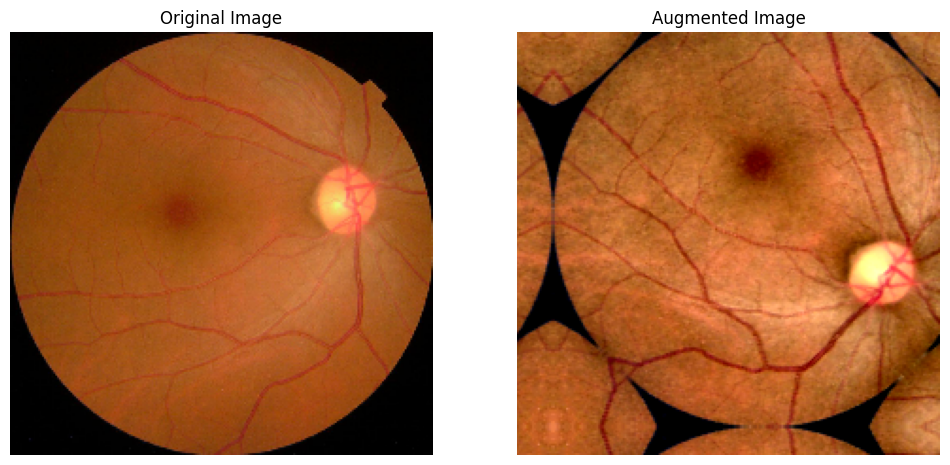

In [11]:
# Select a random image from the training DataFrame
sample_image_path = train_df.sample(1, random_state=1).iloc[0]['image_path']

# Load the image using OpenCV (or PIL/Keras load_img)
original_img = cv2.imread(sample_image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
original_img = cv2.resize(original_img, IMG_SIZE) # Resize to target size

# Convert to TensorFlow tensor and add batch dimension
img_tensor = tf.convert_to_tensor(original_img, dtype=tf.float32)
img_tensor = tf.expand_dims(img_tensor, axis=0) # Add batch dimension

# Apply the augmentation sequence
augmented_img_tensor = img_augmentation(img_tensor, training=True) # training=True enables random augmentations

# Convert augmented image back to NumPy array for display
augmented_img = augmented_img_tensor.numpy()[0]

# Ensure values are in displayable range (e.g., [0, 255] for uint8 or [0, 1] for float)
# The img_augmentation layers (like RandomContrast) keep values generally within 0-255.
# If CLAHE or other ops push values outside, it's good practice to clip or normalize for display.
augmented_img = np.clip(augmented_img, 0, 255).astype(np.uint8)

# Plot original and augmented images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(augmented_img)
plt.title('Augmented Image')
plt.axis('off')

plt.show()

In [ ]:
def load_and_preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis = 0)
    return preprocess_input(img_array)
    # return img_array

In [12]:
train_df.describe()

,id_code,diagnosis,image_path,train_images
count,2930,2930,2930,2930
unique,2930,5,2930,2930
top,e4d3d437b0a8,0,/content/drive/MyDrive/aptos2019/train_images/...,e4d3d437b0a8.png
freq,1,1434,1,1


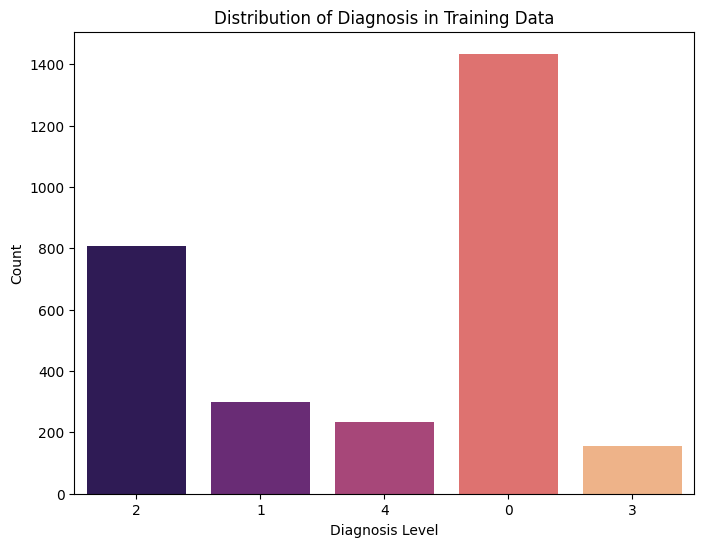

In [13]:
# bar plot on diagnosis
plt.figure(figsize=(8, 6))
sns.countplot(data=train_df, x='diagnosis', palette='magma', hue='diagnosis')
plt.title('Distribution of Diagnosis in Training Data')
plt.xlabel('Diagnosis Level')
plt.ylabel('Count')
plt.show()

In [14]:
train_df['diagnosis'].value_counts()

,count
diagnosis,
0,1434
2,808
1,300
4,234
3,154


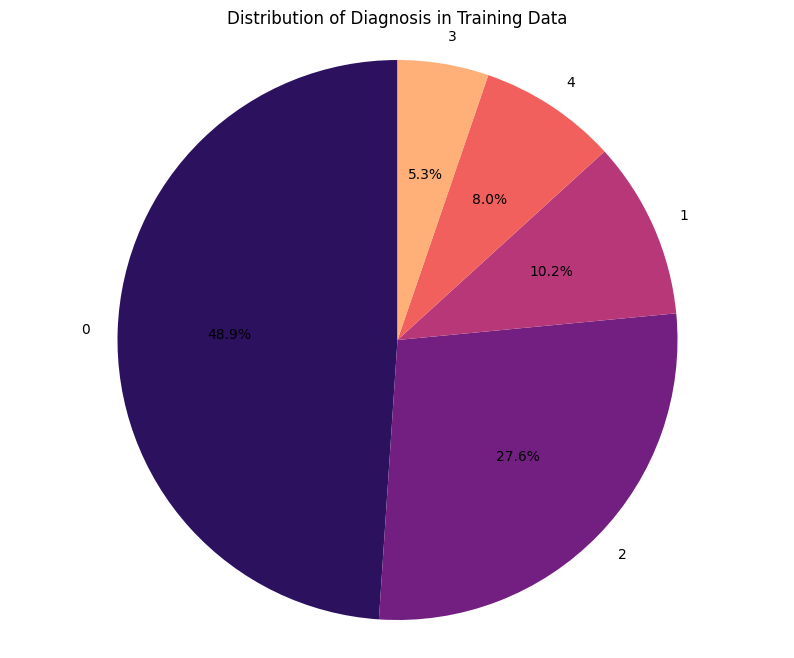

In [15]:
# pie chart on diagnosis
diagnosis_counts = train_df['diagnosis'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('magma', len(diagnosis_counts)))
plt.title('Distribution of Diagnosis in Training Data')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [16]:
((train_df['diagnosis'].value_counts())/len(train_df))*100

,count
diagnosis,
0,48.941980
2,27.576792
1,10.238908
4,7.986348
3,5.255973


### Sample Images from Training Data

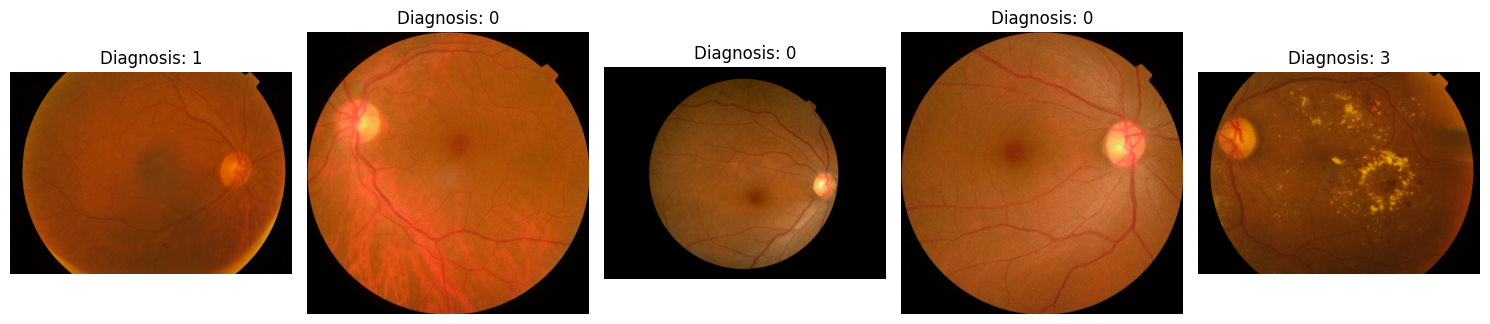

In [17]:
num_samples = 5
sample_df = train_df.sample(n=num_samples, random_state=42)

plt.figure(figsize=(15, 10))
for i, row in enumerate(sample_df.itertuples()):
    image_path = row.image_path
    diagnosis = row.diagnosis

    img = cv2.imread(image_path)
    if img is not None:
        # Convert BGR to RGB for matplotlib display
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img_rgb)
        plt.title(f'Diagnosis: {diagnosis}')
        plt.axis('off')
    else:
        print(f"Could not load image: {image_path}")
plt.tight_layout()
plt.show()

# Build Model

In [ ]:
# Load the EfficientNetV2S base model without the top (classification) layer
base_model = EfficientNetV2S(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')

# Freeze the base model layers
base_model.trainable = False

# Create a new model on top of the base model using the Functional API
inputs = keras.Input(shape=IMG_SIZE + (3,))
x = img_augmentation(inputs) # Apply custom augmentation
x = preprocess_input(x) # EfficientNetV2S expects inputs in the [-1, 1] range after preprocessing
x = base_model(x, training=False) # Pass through the pre-trained base model
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### input data batch generation

In [18]:
train_batches = ImageDataGenerator().flow_from_dataframe(
        dataframe=train_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

valid_batches = ImageDataGenerator().flow_from_dataframe(
        dataframe=valid_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

test_batches = ImageDataGenerator().flow_from_dataframe(
        dataframe=test_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE, shuffle=False)

Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.


### training model

In [19]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-4)

In [ ]:
history = model.fit(train_batches, epochs=20, validation_data=valid_batches, verbose=1, callbacks=[early_stopping, reduce_lr])

In [20]:
model_path = pass
mode.save(model_path)

SyntaxError: invalid syntax (3592746940.py, line 1)

### Load Model and Continue Training

In [21]:
model_file_path = '/content/drive/MyDrive/ML Projects/trained_models/Effnet_model_with_CLAHE/modifiedEffnet.keras'
# Load the previously saved model
print(f"Loading model from {model_file_path}")
loaded_model = tf.keras.models.load_model(model_file_path,
                                          custom_objects={'apply_clahe_batch': apply_clahe_batch}) # Include custom objects if any

print("Model loaded successfully. Summary of loaded model:")
loaded_model.summary()

Loading model from /content/drive/MyDrive/ML Projects/trained_models/Effnet_model_with_CLAHE/modifiedEffnet.keras
Model loaded successfully. Summary of loaded model:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ img_augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,350,577 (77.63 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

 Optimizer params: 12,812 (50.05 KB)

In [ ]:
# Continue training the loaded model for additional epochs
print("Continuing training the loaded model...")
# You can adjust the number of additional epochs here
additional_epochs = 10

history_continued = loaded_model.fit(train_batches,
                                       epochs=additional_epochs, # Train for additional epochs
                                       validation_data=valid_batches,
                                       verbose=1,
                                       callbacks=[early_stopping, reduce_lr])

print("Training continued successfully.")
# You can optionally save the model again after continued training
loaded_model.save('/content/drive/MyDrive/ML Projects/trained_models/Effnet_model_with_CLAHE/modifiedEffnet_continued.keras')
modifiedEffnet_continued_training = pd.DataFrame(history_continued.history)
modifiedEffnet_continued_training.to_csv('/content/drive/MyDrive/ML Projects/trained_models/Effnet_model_with_CLAHE/modifiedEffnet_continued_training.csv')

Continuing training the loaded model...
Epoch 1/10
 7/92 ━━━━━━━━━━━━━━━━━━━━ 28:16 20s/step - accuracy: 0.6727 - loss: 0.7924